# Study assistant graph

`notes` runs first. `quiz` and `flashcards` fan out from it in parallel,
then `deep_dive` joins them and produces the long streamed answer.

Chains live in `chains.py`, graph wiring in `graph.py`.

In [1]:
import os, getpass
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv())


if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("OPENAI_API_KEY: ")

In [2]:
import importlib

import app.chains
import app.graph as graph_module
import app.transformers
from langgraph.checkpoint.memory import InMemorySaver

# for module in (chains, graph_module, transformers):
#     importlib.reload(module)

model = graph_module.get_model("gpt-4o-mini", temperature=0.3)
graph = graph_module.build_study_graph(checkpointer=InMemorySaver(), model=model)

print(sorted(n for n in graph.get_graph().nodes if not n.startswith("__")))

['deep_dive', 'flashcards', 'notes', 'quiz']


## Full run

`invoke` runs every node and returns the accumulated state.

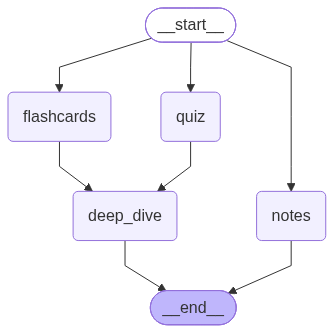

In [3]:
graph

In [4]:
from uuid import uuid4

TOPIC = "how vector embeddings work"

config = {"configurable": {"thread_id": str(uuid4())}}

state = graph.invoke(
    {"topic": TOPIC, "num_questions": 4, "num_cards": 6}, config=config
)
# sorted(state)

In [5]:
config

{'configurable': {'thread_id': 'b267a4dc-5a95-4a0e-9009-e6b098119e76'}}

In [6]:
from app.threads import get_thread_state

snapshot = await graph.aget_state(config=config)
ser_state = await get_thread_state(graph, thread_id=config['configurable']['thread_id'])


In [40]:
ser_state['values'] == state

True

In [47]:
messages = [1, 2, 3]
# messages = None

res = {"foo": 10, **({"messages": messages} if messages else {})}
res

{'foo': 10, 'messages': [1, 2, 3]}

In [36]:
ser_state.get('values', {})

{'topic': 'how vector embeddings work',
 'num_questions': 4,
 'num_cards': 6,
 'notes': '# Revision Notes: How Vector Embeddings Work\n\n## What are Vector Embeddings?\n\nVector embeddings are numerical representations of objects, such as words, sentences, or images, in a continuous vector space. Each object is mapped to a point in this space, allowing for mathematical operations and comparisons.\n\n## Purpose of Vector Embeddings\n\nThe main purpose of vector embeddings is to capture the semantic meaning of objects. By representing similar objects as nearby points in the vector space, embeddings enable various machine learning tasks, such as:\n\n- **Natural Language Processing (NLP)**: Understanding and generating human language.\n- **Image Recognition**: Identifying and classifying images.\n- **Recommendation Systems**: Suggesting products or content based on user preferences.\n\n## How Vector Embeddings are Created\n\nVector embeddings are typically created using techniques such as:

In [10]:
import asyncio

from transformers import FlashcardTransformer, QuizTransformer

stream = await graph.astream_events(
    {"topic": TOPIC, "num_questions": 4, "num_cards": 6},
    version="v3",
    transformers=[QuizTransformer, FlashcardTransformer],
)

In [11]:
async def consume_quiz():
    async for event in stream.quiz_question:
        print(event)


async def consume_flashcard():
    async for event in stream.flashcard:
        print(event)


response = await asyncio.gather(
    consume_quiz(),
    consume_flashcard(),
)


{'id': 1, 'front': 'What is a vector embedding?', 'back': 'A vector embedding is a numerical representation of an object, such as a word or image, in a continuous vector space. It captures semantic meaning and relationships between objects.', 'hint': 'Think of it as a way to represent complex data in simpler terms.', 'tags': ['vector', 'embedding', 'machine learning']}
{'id': 1, 'question': 'What is the primary purpose of vector embeddings in machine learning?', 'options': ['To represent data in a high-dimensional space', 'To reduce the size of datasets', 'To increase the complexity of models', 'To visualize data in 2D'], 'answer': 'To represent data in a high-dimensional space', 'difficulty': 'easy', 'explanation': 'Vector embeddings are used to convert data into numerical representations that can capture semantic relationships in a high-dimensional space.'}
{'id': 2, 'front': 'How are vector embeddings created?', 'back': 'Vector embeddings are created using techniques like Word2Vec, 

In [8]:
async def consume(channel, label):
    items = []

    async for item in channel:
        items.append(item)
        print(f"{label} {item['id']}: {item.get('question') or item.get('front')}")

    return items


questions, cards = await asyncio.gather(
    consume(stream.quiz_question, "quiz"),
    consume(stream.flashcard, "card"),
)

print(f"\n{len(questions)} questions, {len(cards)} cards")

card 1: What are vector embeddings?
quiz 1: What is the primary purpose of vector embeddings in machine learning?
card 2: How are vector embeddings generated?
quiz 2: Which of the following is a common application of vector embeddings?
card 3: What is the purpose of using vector embeddings?
quiz 3: How do vector embeddings help in measuring similarity between data points?
card 4: What is dimensionality reduction in the context of embeddings?
card 5: What role does cosine similarity play in vector embeddings?
quiz 4: What is a key benefit of using pre-trained vector embeddings?
card 6: How do vector embeddings improve natural language processing?

4 questions, 6 cards


In [ ]:
# start here

## HTTP client for `app/server.py`

Five routes, all thread-scoped:

| Method | Path | What it does |
| --- | --- | --- |
| `POST` | `/threads/{thread_id}/commands` | send a `run.start` command, get a `run_id` back |
| `POST` | `/threads/{thread_id}/stream` | SSE subscription to that thread's protocol events |
| `GET` | `/threads/{thread_id}/state` | latest checkpoint as a `ThreadState` |
| `POST` | `/threads/{thread_id}/state` | write values into the thread |
| `POST` | `/threads/{thread_id}/history` | list past checkpoints, newest first |

Start the server in another terminal first:

```bash
uv run app          # or: uv run python -m app.main
```

In [1]:
import json
import uuid
from collections.abc import Iterator
from typing import Any

import httpx

BASE_URL = "http://127.0.0.1:8000"
THREAD_ID = "notebook-demo"

### SSE helpers

`/stream` speaks `text/event-stream` and the server keeps the connection open
after a run ends. That is the protocol's design, not an oversight. From the
Agent Streaming Protocol README: "Each SSE connection is its own subscription.
Closing the connection unsubscribes from that stream." A subscription is scoped
to the thread and survives run boundaries, so the client is the one that decides
when to hang up.

The cue is the graph advancing to `__end__`. Node names ride on the
`checkpoints`, `tasks` and `updates` channels, and this server's v3 stream emits
none of them, so `reached_end_node` never fires against it as it stands today.
What does fire is the root-namespace `lifecycle` event that
`LocalThreadSession._start_run` publishes when the run unwinds, so that is the
fallback. It also covers the runs that stop without reaching `__end__`, which is
what `failed` and `interrupted` are.

In [4]:
END_NODE = "__end__"
TERMINAL_LIFECYCLE = {"completed", "failed", "interrupted"}


def iter_sse(response: httpx.Response) -> Iterator[dict[str, Any]]:
    """Decode the `data:` frames of an event-stream response into dicts."""
    data_lines: list[str] = []
    for line in response.iter_lines():
        if line == "":
            if data_lines:
                yield json.loads("\n".join(data_lines))
                data_lines = []
            continue
        if line.startswith("data:"):
            data_lines.append(line[5:].lstrip())
    if data_lines:
        yield json.loads("\n".join(data_lines))


def reached_end_node(event: dict[str, Any]) -> bool:
    """True when an event reports the root graph advancing to `__end__`.

    A subgraph reaching its own `__end__` is not the run finishing, so this
    only looks at the root namespace.
    """
    params = event.get("params") or {}
    if params.get("namespace"):
        return False
    data = params.get("data")
    if not isinstance(data, dict):
        return False

    method = event.get("method")
    if method == "checkpoints":
        return END_NODE in (data.get("next") or [])
    if method == "tasks":
        return data.get("name") == END_NODE
    if method == "updates":
        return END_NODE in data
    return False


def is_run_finished(event: dict[str, Any]) -> bool:
    """True once the reader should hang up."""
    if reached_end_node(event):
        return True

    params = event.get("params") or {}
    data = params.get("data") or {}
    return (
        event.get("method") == "lifecycle"
        and params.get("namespace") == []
        and data.get("event") in TERMINAL_LIFECYCLE
    )

### The client

One method per route.

In [5]:
class StudyClient:
    """Plain-httpx client for the routes in `app/server.py`."""

    def __init__(self, base_url: str = BASE_URL, timeout: float = 300.0) -> None:
        self._http = httpx.Client(base_url=base_url, timeout=timeout)

    def close(self) -> None:
        self._http.close()

    def __enter__(self) -> "StudyClient":
        return self

    def __exit__(self, *exc: object) -> None:
        self.close()

    # POST /threads/{thread_id}/commands
    def run_start(
        self,
        thread_id: str,
        graph_input: dict[str, Any],
        *,
        command_id: str | None = None,
    ) -> dict[str, Any]:
        """Kick off a graph run. Returns immediately with a `run_id`; the run
        itself proceeds in the background and shows up on `/stream`."""
        command = {
            "id": command_id or str(uuid.uuid4()),
            "method": "run.start",
            "params": {"input": graph_input},
        }
        response = self._http.post(f"/threads/{thread_id}/commands", json=command)
        response.raise_for_status()
        return response.json()

    # POST /threads/{thread_id}/stream
    def stream(
        self,
        thread_id: str,
        *,
        channels: list[str] | None = None,
        namespaces: list[list[str]] | None = None,
        depth: int | None = None,
        since: int | None = None,
        stop_when_finished: bool = True,
    ) -> Iterator[dict[str, Any]]:
        """Subscribe to a thread's protocol events.

        Buffered events are replayed on connect, so subscribing after
        `run_start` still yields the whole run. `since` skips everything up to
        and including that `seq`.
        """
        params: dict[str, Any] = {}
        if channels is not None:
            params["channels"] = channels
        if namespaces is not None:
            params["namespaces"] = namespaces
        if depth is not None:
            params["depth"] = depth
        if since is not None:
            params["since"] = since

        with self._http.stream(
            "POST", f"/threads/{thread_id}/stream", json=params
        ) as response:
            response.raise_for_status()
            for event in iter_sse(response):
                yield event
                if stop_when_finished and is_run_finished(event):
                    return

    # GET /threads/{thread_id}/state
    def get_state(self, thread_id: str) -> dict[str, Any]:
        """404s until the thread has at least one checkpoint."""
        response = self._http.get(f"/threads/{thread_id}/state")
        response.raise_for_status()
        return response.json()

    # POST /threads/{thread_id}/state
    def update_state(
        self,
        thread_id: str,
        values: dict[str, Any] | None = None,
        *,
        checkpoint: dict[str, Any] | None = None,
        as_node: str | None = None,
    ) -> dict[str, Any]:
        """Write values into the thread and return the resulting state."""
        body: dict[str, Any] = {"values": values}
        if checkpoint is not None:
            body["checkpoint"] = checkpoint
        if as_node is not None:
            body["as_node"] = as_node
        response = self._http.post(f"/threads/{thread_id}/state", json=body)
        response.raise_for_status()
        return response.json()

    # POST /threads/{thread_id}/history
    def get_history(
        self,
        thread_id: str,
        *,
        limit: int = 10,
        before: str | dict[str, Any] | None = None,
    ) -> list[dict[str, Any]]:
        """Checkpoint snapshots, newest first. `before` is a checkpoint id."""
        body: dict[str, Any] = {"limit": limit}
        if before is not None:
            body["before"] = before
        response = self._http.post(f"/threads/{thread_id}/history", json=body)
        response.raise_for_status()
        return response.json()


client = StudyClient(BASE_URL)

### 1. `POST /threads/{thread_id}/commands`

Starts a run and returns the `run_id`. It does not wait for the graph.

In [6]:
ack = client.run_start(
    THREAD_ID,
    {"topic": "how vector embeddings work", "num_questions": 4, "num_cards": 6},
)

print(json.dumps(ack, indent=2))
run_id = ack["result"]["run_id"]

{
  "type": "success",
  "id": "7b0bbccb-6ac1-4dff-9f47-abece0823827",
  "result": {
    "run_id": "81da698c-4b0f-4074-a080-8b817481d739"
  }
}


### 2. `POST /threads/{thread_id}/stream`

Replays the buffer for the run started above, then follows it live until the
terminal `lifecycle` event.

`channels` narrows what comes back. This graph emits `lifecycle`, `values` and
`messages`; `messages` is per-token, so a single run is a few thousand frames.
The other protocol channels are `updates`, `checkpoints`, `tools`, `custom`,
`tasks` and `input.requested`.

In [7]:
for event in client.stream(THREAD_ID, channels=["lifecycle", "values"]):
    method = event["method"]
    namespace = "/".join(event["params"].get("namespace") or []) or "<root>"
    data = event["params"].get("data")
    summary = sorted(data) if isinstance(data, dict) else data
    print(f"[{event.get('seq')}] {method:<10} {namespace:<12} {summary}")

[0] lifecycle  <root>       ['event']
[1] values     <root>       ['num_cards', 'num_questions', 'topic']
[1557] values     <root>       ['flashcards', 'notes', 'num_cards', 'num_questions', 'quiz', 'topic']
[2730] values     <root>       ['deep_dive', 'flashcards', 'notes', 'num_cards', 'num_questions', 'quiz', 'topic']
[2731] lifecycle  <root>       ['event']


### 3. `GET /threads/{thread_id}/state`

The latest checkpoint. Raises `404` if the thread has never run.

In [8]:
state = client.get_state(THREAD_ID)

print("next:      ", state["next"])
print("checkpoint:", state["checkpoint"]["checkpoint_id"])
print("values:    ", sorted(state["values"]))
print()
print(state["values"]["notes"][:400])

next:       []
checkpoint: 1f1a9cd7-9bd7-6c20-8002-0cf2b41b221c
values:     ['deep_dive', 'flashcards', 'notes', 'num_cards', 'num_questions', 'quiz', 'topic']

# Revision Notes: How Vector Embeddings Work

## What are Vector Embeddings?

Vector embeddings are numerical representations of objects, such as words, sentences, or images, in a continuous vector space. Each object is mapped to a point in this space, allowing for mathematical operations and comparisons.

## Purpose of Vector Embeddings

The main purpose of vector embeddings is to capture the sem


### 4. `POST /threads/{thread_id}/state`

Writes values into the thread. With no `as_node` the server writes through
`__start__`, which re-arms the entry nodes, so `next` comes back populated.

In [9]:
updated = client.update_state(THREAD_ID, {"num_questions": 8})

print("num_questions:", updated["values"]["num_questions"])
print("next:         ", updated["next"])
print("checkpoint:   ", updated["checkpoint"]["checkpoint_id"])

num_questions: 8
next:          ['notes', 'quiz', 'flashcards']
checkpoint:    1f1a9cd8-22c7-6e81-8003-a2c292ee1428


### 5. `POST /threads/{thread_id}/history`

Checkpoint snapshots, newest first. `before` takes a checkpoint id to page back.

Heads up: as written this route answers `422`. Its handler is declared
`async def _post_history(self, request: Request)`, and FastAPI reads that
leading `self` as a required query parameter. Dropping it from the signature
fixes the route; the closure already has `self`.

In [10]:
history = client.get_history(THREAD_ID, limit=5)

for snapshot in history:
    checkpoint_id = snapshot["checkpoint"]["checkpoint_id"]
    source = snapshot["metadata"].get("source")
    print(f"{checkpoint_id}  next={snapshot['next']!s:<40} source={source}")

1f1a9cd8-22c7-6e81-8003-a2c292ee1428  next=['notes', 'quiz', 'flashcards']          source=update
1f1a9cd7-9bd7-6c20-8002-0cf2b41b221c  next=[]                                       source=loop
1f1a9cd7-4783-6637-8001-60500c13948a  next=['deep_dive']                            source=loop
1f1a9cd7-17c1-60b0-8000-d337a169aa37  next=['notes', 'quiz', 'flashcards']          source=loop
1f1a9cd7-17af-661e-bfff-dd4a3960827b  next=['__start__']                            source=input


### Cleanup

In [11]:
client.close()

## The same five calls through the LangGraph SDK

`langgraph_sdk` speaks this protocol natively, so four of the five routes need no
adapter at all:

| Server route | SDK call |
| --- | --- |
| `POST /threads/{thread_id}/commands` | `thread.run.start(input=...)` |
| `GET /threads/{thread_id}/state` | `sdk.threads.get_state(thread_id)` |
| `POST /threads/{thread_id}/state` | `sdk.threads.update_state(thread_id, values)` |
| `POST /threads/{thread_id}/history` | `sdk.threads.get_history(thread_id, limit=...)` |

The fifth does not line up, and this server is the side that matches the spec.
The protocol README and the `react-custom-backend` cookbook both put the SSE
subscription at `POST /threads/:thread_id/stream`, which is exactly what
`app/server.py` serves. The installed `langgraph_sdk` 0.4.4 posts to
`/threads/{thread_id}/stream/events` instead, so its event stream answers `404`
here while `run.start` on the same session succeeds.

Two ways out: pin an SDK whose transport matches, or accept both paths on the
server with one alias.

```python
app.add_api_route("/threads/{thread_id}/stream/events", _stream, methods=["POST"])
```

The next cell does neither and rewrites the path client-side, so the notebook
runs against the server as it stands.

In [2]:
import asyncio
import httpx

from langgraph_sdk import get_client

SDK_THREAD_ID = "notebook-sdk"

import json
import uuid
from collections.abc import Iterator
from typing import Any

import httpx

import logging

logging.basicConfig(
    level="INFO",
    format="%(levelname)s:  %(name)s - %(message)s",
    force=True,
)
logger = logging.getLogger(__name__)


BASE_URL = "http://127.0.0.1:8000"
THREAD_ID = "notebook-demo"


class StreamPathRewrite(httpx.AsyncBaseTransport):
    """Point the SDK's subscribe path at the route this server actually serves."""

    def __init__(self, inner: httpx.AsyncBaseTransport) -> None:
        self._inner = inner

    async def handle_async_request(self, request: httpx.Request) -> httpx.Response:
        if request.url.path.endswith("/stream/events"):
            request.url = request.url.copy_with(
                path=request.url.path.removesuffix("/events")
            )
        return await self._inner.handle_async_request(request)


# api_key=None stops the SDK auto-loading LANGSMITH_API_KEY from .env and
# sending it to a local server that has no use for it.
sdk_client = get_client(url=BASE_URL)
# sdk.http.client._transport = StreamPathRewrite(sdk.http.client._transport)

### 1 and 2. `run.start` and the subscription

`sdk.threads.stream(...)` opens one session covering both routes. `assistant_id`
is required by the SDK and ignored by this server, which reads only
`params.input` off the command.

Iterate a typed projection rather than `thread.events`. `thread.events` is a raw
subscription and ends only when the connection closes, which for a thread-scoped
subscription means when you close it. Sitting in `async for event in
thread.events` therefore waits forever, even though the events all arrive: one
run measured here delivered 2140 `messages`, 3 `values` and 2 `lifecycle` events
before the reader gave up.

`thread.values`, `thread.messages` and `thread.output` are the answer. A
lifecycle watcher inside the session ends them on the run's terminal event, and
`async with` closes the connection on the way out. That watcher is doing exactly
what `is_run_finished` does in the hand-rolled client above.

The first two snapshots are the same state twice. `thread.values` seeds itself
with `GET /threads/{id}/state` before subscribing, and the run's opening `values`
event then repeats it.

In [2]:
# assistants = await sdk_client.assistants.search()

In [3]:
thread = await sdk_client.threads.create(thread_id="foo-1", if_exists="do_nothing", metadata={"some": "metadata"})

INFO:  httpx - HTTP Request: POST http://127.0.0.1:8000/threads "HTTP/1.1 200 OK"


In [6]:
from langgraph_sdk import get_client
import asyncio

client = sdk_client
TOPIC = "how vector embeddings work"

# async with client.threads.stream(
#     thread_id="foo-1",
#     assistant_id="agent",
# ) as thread:
#     await thread.run.start(input={"topic": TOPIC, "num_questions": 4, "num_cards": 6})
    
    

#     # Start all consumers concurrently so they share one SSE connection.
#     async def get_messages():
#         print("triggered get_messages")
#         return [s async for s in thread.messages]

#     async def get_tool_calls():
#         print("triggered get_tool_calls")
#         return [c async for c in thread.tool_calls]
    
#     # async def whole_thread():
#     #     print("thread: ", thread)

#     messages, tool_calls = await asyncio.gather(get_messages(), get_tool_calls())

#     # for stream in messages:
#     #     print(await stream.text)  # accumulated text

#     final = await thread.output  # terminal state values

In [16]:
async with sdk_client.threads.stream(
    thread_id="my-thread-6", assistant_id="agent"
) as thread:
    await thread.run.start(input={"topic": TOPIC, "num_questions": 4, "num_cards": 6})

    async def get_quizzes():
        print("triggered get_quizzes")
        quiz = []
        async for question in thread.extensions["quiz_question"]:
            print(question)
            quiz.append(question)
        return quiz

    async def get_flashcards():
        print("triggered get_flashcards")
        flashcards = []
        async for flashcard in thread.extensions["flashcard"]:
            print(flashcard)
            flashcards.append(flashcard)
        return flashcards

    quiz, flashcards = await asyncio.gather(get_quizzes(), get_flashcards())
    
    final = await thread.output

INFO:  httpx - HTTP Request: POST http://127.0.0.1:8000/threads/my-thread-6/commands "HTTP/1.1 200 OK"
INFO:  httpx - HTTP Request: POST http://127.0.0.1:8000/threads/my-thread-6/stream/events "HTTP/1.1 200 OK"
INFO:  httpx - HTTP Request: POST http://127.0.0.1:8000/threads/my-thread-6/stream/events "HTTP/1.1 200 OK"
INFO:  httpx - HTTP Request: POST http://127.0.0.1:8000/threads/my-thread-6/stream/events "HTTP/1.1 200 OK"


triggered get_quizzes
triggered get_flashcards
{'name': 'flashcard', 'payload': {'id': 1, 'front': 'What are vector embeddings?', 'back': 'Vector embeddings are numerical representations of objects, such as words or images, in a continuous vector space. They capture semantic meanings and relationships between the objects.', 'hint': None, 'tags': ['vector', 'embeddings', 'representation']}}
{'name': 'quiz_question', 'payload': {'id': 1, 'question': 'What is the primary purpose of vector embeddings in machine learning?', 'options': ['To represent data in a lower-dimensional space', 'To increase the complexity of models', 'To eliminate the need for data preprocessing', 'To create random data points'], 'answer': 'To represent data in a lower-dimensional space', 'difficulty': 'easy', 'explanation': 'Vector embeddings are used to represent high-dimensional data in a lower-dimensional space, making it easier for models to process and analyze.'}}
{'name': 'flashcard', 'payload': {'id': 2, 'fro

INFO:  httpx - HTTP Request: GET http://127.0.0.1:8000/threads/my-thread-6/state "HTTP/1.1 200 OK"


{'name': 'quiz_question', 'payload': {'id': 4, 'question': 'How do vector embeddings help in improving model performance?', 'options': ['By increasing the number of features', 'By reducing overfitting', 'By capturing semantic relationships', 'By simplifying the model architecture'], 'answer': 'By capturing semantic relationships', 'difficulty': 'hard', 'explanation': 'Vector embeddings capture semantic relationships between data points, allowing models to better understand and generalize patterns in the data, thus improving performance.'}}
{'name': 'flashcard', 'payload': {'id': 6, 'front': 'How do vector embeddings improve machine learning models?', 'back': 'Vector embeddings improve machine learning models by providing a more compact and informative representation of data, which can enhance model performance and reduce computational costs. They allow models to generalize better from training data.', 'hint': None, 'tags': ['machine learning', 'performance', 'generalization']}}


In [17]:
quiz, flashcards

([{'name': 'quiz_question',
   'payload': {'id': 1,
    'question': 'What is the primary purpose of vector embeddings in machine learning?',
    'options': ['To represent data in a lower-dimensional space',
     'To increase the complexity of models',
     'To eliminate the need for data preprocessing',
     'To create random data points'],
    'answer': 'To represent data in a lower-dimensional space',
    'difficulty': 'easy',
    'explanation': 'Vector embeddings are used to represent high-dimensional data in a lower-dimensional space, making it easier for models to process and analyze.'}},
  {'name': 'quiz_question',
   'payload': {'id': 2,
    'question': 'Which of the following is a common application of vector embeddings?',
    'options': ['Image recognition',
     'Text similarity',
     'Data encryption',
     'Network security'],
    'answer': 'Text similarity',
    'difficulty': 'medium',
    'explanation': 'Vector embeddings are widely used in natural language processing to

In [ ]:
async with sdk.threads.stream(thread_id=SDK_THREAD_ID, assistant_id="study") as thread:
    ack = await thread.run.start(
        input={"topic": "how vector embeddings work", "num_questions": 4, "num_cards": 6}
    )
    print("run_id:", ack["run_id"], "\n")

    async for snapshot in thread.values:
        print("values:", sorted(snapshot))

    final = await thread.output

print()
print(final["deep_dive"][:400])

### `thread.messages`, `params.node`, and what the server drops

This file is written against the JS client. Three comments say so outright, and
the cookbook it is ported from exists "so the existing React frontend can use
`HttpAgentServerAdapter` against a Python server". But `unwrap_protocol_data` is
not a JS-only shim. It produces exactly the `MessagesData` the spec defines, and
the JS and Python bindings of that type are identical.

The omission is one field up. The spec puts the routing hint on the envelope:

```ts
export interface MessagesEvent {
  method: "messages";
  params: {
    namespace: Namespace;
    timestamp: Timestamp;
    node?: string;        // Graph node that produced this event
    data: MessagesData;
  };
}
```

This server never sets `params.node`, because the only place `langgraph_node`
exists is the metadata half of the raw v3 `(payload, metadata)` pair, and
`unwrap_protocol_data` keeps `data[0]` and drops the rest. In process there is no
such loss: `run.messages` on `graph.astream_events(..., version="v3")` handles
this graph fine, yielding four streams attributed to `quiz`, `flashcards`,
`notes` and `deep_dive`, all finishing with their full text.

The two SDKs then part ways, and that is why one fix is not enough.

`MessageAssembler` in the JS SDK keys on `namespace::node::messageId`. Without
`params.node` every concurrent call collides on one slot. The cookbook survives
only because its ReAct agent has a single model call in flight; `notes`, `quiz`
and `flashcards` all fan out from `START`, so this graph would break the JS
client too.

`MessagesDecoder` in `langgraph_sdk` 0.4.4 ignores `params.node` entirely. It
routes on the payload `id`, which the spec puts only on `message-start`, and
falls back to a slot that resolves while exactly one stream is open. Feeding it
synthetic frames with `params.node` correctly set still drops every delta and
every `message-finish`. It also reads the node from
`data["metadata"]["langgraph_node"]` rather than from `params`.

So the server needs both. Lift the node onto the envelope for the spec and for
JS, and stamp the id onto continuation frames for the Python SDK. The payload
types are `Extensible`, so the extra id is an allowed extension rather than a
schema violation.

```python
def sanitize_event(event: ProtocolEvent) -> ProtocolEvent:
    params = dict(event["params"])
    method = event.get("method", "")
    data = params.get("data")

    # The metadata half is the only source of langgraph_node, and the spec
    # carries it on params.node. Lift it before unwrap throws it away.
    if method in {"messages", "tools"} and isinstance(data, (tuple, list)) and len(data) > 1:
        metadata = data[1]
        if isinstance(metadata, dict) and metadata.get("langgraph_node"):
            params.setdefault("node", metadata["langgraph_node"])

    params["data"] = sanitize_for_json(unwrap_protocol_data(method, data))
    if "interrupts" in params:
        params["interrupts"] = sanitize_for_json(params["interrupts"])
    return {**event, "params": params}


def unwrap_protocol_data(method: str, data: Any) -> Any:
    if method not in {"messages", "tools"}:
        return data
    if not isinstance(data, (tuple, list)) or not data:
        return data
    payload = data[0]
    if not isinstance(payload, dict) or "event" not in payload:
        return data

    metadata = data[1] if len(data) > 1 and isinstance(data[1], dict) else {}

    # langgraph_sdk routes on the payload id, which the spec puts only on
    # message-start. message-start already uses this exact value.
    run_id = metadata.get("run_id")
    if run_id and "id" not in payload:
        payload = {**payload, "id": f"lc_run--{run_id}"}

    # ...and it reads the node from the payload metadata, not from params.
    node = metadata.get("langgraph_node")
    if node and payload.get("event") == "message-start":
        inner = dict(payload.get("metadata") or {})
        inner.setdefault("langgraph_node", node)
        payload = {**payload, "metadata": inner}
    return payload
```

Measured against this graph through `langgraph_sdk`:

| `unwrap_protocol_data` | deltas per stream | streams that finished | `message.node` |
| --- | --- | --- | --- |
| as written | 6, 0, 0, 0 | 0 of 4 | `None` |
| run id stamped on every frame | 93, 612, 113, 1397 | 4 of 4 | `None` |
| plus `langgraph_node` on `message-start` | 590, 112, 101, 1400 | 4 of 4 | correct |

The cell below hangs against the server as it stands, and streams once the patch
is in.

In [ ]:
async def collect(message):
    """`message.text` is an async iterable of deltas and awaitable for the whole."""
    return message.node, await message.text


async with sdk.threads.stream(thread_id="notebook-sdk-tokens", assistant_id="study") as thread:
    await thread.run.start(input={"topic": "b-trees", "num_questions": 1, "num_cards": 1})

    # Consume the streams concurrently. The outer loop is what feeds chunks into
    # them, so blocking inside the loop body deadlocks every one.
    collectors = []
    async for message in thread.messages:
        collectors.append(asyncio.create_task(collect(message)))

    for node, text in await asyncio.gather(*collectors):
        print(f"{node!s:<12} {len(text):>6} chars  {text[:60]!r}")

### 3. `GET /threads/{thread_id}/state`

In [ ]:
state = await sdk.threads.get_state(SDK_THREAD_ID)

print("next:      ", state["next"])
print("checkpoint:", state["checkpoint"]["checkpoint_id"])
print("values:    ", sorted(state["values"]))

### 4. `POST /threads/{thread_id}/state`

In [ ]:
updated = await sdk.threads.update_state(SDK_THREAD_ID, {"num_questions": 8})

print("num_questions:", updated["values"]["num_questions"])
print("next:         ", updated["next"])
print("checkpoint:   ", updated["checkpoint"]["checkpoint_id"])

### 5. `POST /threads/{thread_id}/history`

In [ ]:
history = await sdk.threads.get_history(SDK_THREAD_ID, limit=5)

for snapshot in history:
    checkpoint_id = snapshot["checkpoint"]["checkpoint_id"]
    source = snapshot["metadata"].get("source")
    print(f"{checkpoint_id}  next={snapshot['next']!s:<40} source={source}")

## Which one to reach for

`StudyClient` is the better place to watch the wire. Every frame arrives raw,
`seq` numbers are visible, and nothing is buffered or reassembled out of sight.

The SDK is the better place to consume a run. `thread.values`, `thread.messages`
and `thread.output` end themselves on the run's terminal lifecycle, which the
hand-rolled client had to be taught to do. It also brings assembled token
streams, subgraph handles, per-event dedup across reconnects, and a `since`
cursor replayed for you after a dropped connection.

Two things stand between this server and the SDK working untouched, and neither
is inherent: the subscribe path the installed SDK expects, and the metadata that
`unwrap_protocol_data` drops on the way to the wire.